## <font color='blue'>ASTR 21100</font>

# <font color='blue'>"*Computational Techniques in Astrophysics*"</font>

## <font color='blue'>a final project option</font>

## <font color='blue'>Estimating redshifts of the most distant galaxies</font>
    
## <font color='blue'>Lead instructor(s) for this project: Raul Teixeira, Andrey Kravtsov </font>
    
### <font color='blue'>Undergraduate students: 50 points + possible extra credit points</font>
        

### <font color='blue'>Part I is due Fri, Feb 23 by 9pm; Part II is due Fri, Mar 1 , 9pm</font> 

### <font color='blue'>Final version is due Thu, Mar 7, 9pm</font> 


<p>


<p>
<center>
<img width=500 src="https://astrobites.org/wp-content/uploads/2022/12/JADES-fig1.png"></img>
</center>

import packages needed by the codes below. Run this cell first before using these codes. 

In [1]:
import numpy as np 
import math

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

# the following code make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

## <font color='blue'>Exercise 3 (10 points): determing best fit redshifts using flux measurements of galaxies observed with James Webb Space Telescope</font>


### Background:

Galaxies are distant stellar systems and are one of the main subjects of astronomical research. Expansion of the Universe discovered by Edwin Hubble almost a century ago implies that galaxies at larger distances from us are receding from us with larger velocities. This *recession velocity* is manifested in the shift of the features in a galaxy's spectral energy distribution (spectrum) - the distribution of the emitted photons with their energy $E$ or, equivalently, with wavelength $\lambda$ because photon energy and wavelength are proportional to each other: $E=ch/\lambda$ where $c$ and $h$ are the speed of light and the Planck constant, respectively. 

Thus, by measuring spectra of galaxies we can estimate the magnitude of this spectral shift called redshift, thereby estimating their distance from us. The most distant galaxies discovered in the last couple of years have redshifts of $z\approx 15$, although for such galaxies the estimate of redshift is quite uncertain. For a given $z$, the spectral features are shifted by the factor of $1+z$. Thus a galaxy with $z=10$ has its feaures in the invisible to us ultraviolet light at $\lambda=100$ nm (nanometers) is shifted  all the way across the visible part of the spectral range to the invisible infrared range of 1100 nm. 

The most distant galaxies with the largest redshifts also tend to be the faintest. For faint galaxies it is very difficult to measure a detailed spectrum with high spectral resolution. Instead, fluxes in different broad wavelength ranges (called "bands") are measured and we get a very rough, low-resolution view of the spectrum based on the average flux from these different ranges. 
Measurement of such fluxes is called "photometry" (literally meaning "measuring light") and redshifts estimated using such average fluxes are called "photometric redshifts*. 
In this case, redshift is estimated by fitting a model spectrum (template) to the flux measurements at different wavelengths.

In this project, you will use flux measurements based on the Hubble Space Telescope (HST) and James Webb Space Telescope (JWST) observations from a recent study by [Hainline et al. 2023](https://ui.adsabs.harvard.edu/abs/2023arXiv230602468H/abstract) to estimate photometric redshifts of galaxies. You will use these estimates to search for the most distant galaxies and estimate their distances, intrinsic luminosities and stellar masses. 


### <font color='blue'>Which computational and analysis methods are used in this project</blue>

* Exploration of spectral energy distributions of stellar populations of different age. 
    
    
* Optimization of multi-parameter models with continuous and discrete parameters. 

        
* Estimates of the posterior and uncertainties of redshift estimates using Bayesian analysis and MCMC.
    
    

### <font color='blue'>Spectral Energy Distribution (SED) and the Broadband fluxes</blue>

Suppose a source a spectral energy distribution in the form of flux $f_\lambda$ which is the energy of photons per unit area of the detector per interval of wavelength $d\lambda$. 

If we measure the light from the source using a filter for a spectral band $b$ with the *transmission curve* $T_b(\lambda)$ which is the proportional to the fraction of light the filter is transmitting at each wavelength $\lambda$, the measured flux in this band will be 

$$f_b = \frac{\int f_\lambda(\lambda) T(\lambda)d\lambda}{\int T(\lambda)d\lambda},$$

where integrals are taken within the wavelength range, $[\lambda_{\rm min}, \lambda_{\rm max}]$, within which filter transmission is not zero, $T(\lambda)>0$.  

The codes below read and provide $f_{\lambda}$ for the spectral templates used in the Hainline et al. study and $T(\lambda)$ curves for the filters used in that study. These can be approximated by splines and we can use the splines for approximating integrals in the equation above. Example of how this can be done is shown in the code below. 


***Note*** that the spectral templates $f_\lambda$ are defined as the photon energy flux per wavelength interval $d\lambda$, while measured fluxes in Hainline et al. are defined as $f_\nu$ - the energy flux per frequency interval $d\nu$. The two definitions are related by 

$$f_\nu = f_\lambda \lambda^2/c.$$

Thus, for comparison of the fluxes $f_b$ calculated using equation above with the measured fluxes they need to be multiplied by $\lambda_{\rm pivot}^2$:

$$\tilde{f}_{b} = 10^{n_f}\, f_b \lambda_{\rm pivot}^2,$$
where 
$$\lambda_{\rm pivot}^2 = \frac{\int \lambda T(\lambda)d\lambda}{\int T(\lambda)/\lambda d\lambda}$$
and $n_f$ is normalization of the model SED on a log scale, which is a free parameter of the fit along with redshift and the number of the template. 

The value of $\lambda_{\rm pivot}$ is computed (again using splines) and provided for each filter in the function `read_filters` below. 


### <font color='blue'>Likelihood for the flux measurements of a given source</blue>

Given a source with fluxes measured in $N_f$ of filter bands, $f_{b_i}$ ($i=1,\ldots,N_f$), and their uncertainties $\sigma_{f,i}$, the logarithm of the likelihood that these measurements are described by a given spectral template number $N_t$ with normalization (in log) $n_f$ redshifted by redshift $z$ is 

$$\ln L = -0.5\sum\limits_{i=0}^{N_f} \frac{(f_{b_i}-\tilde{f}_b)^2}{\sigma_{f,i}^2},$$

where, as described above $\tilde{f}_b$ is 

$$\tilde{f}_{b} = 10^{n_f}\, f_b \lambda_{\rm pivot}^2=10^{n_f}\,\lambda_{\rm pivot}^2\frac{\int f_\lambda[\lambda(1+z)] T(\lambda)d\lambda}{\int T(\lambda)d\lambda},$$

and $f_\lambda[\lambda(1+z)]$ is the redshifted model spectral template $N_t$. 

The model parameters of the likelihood are template number $N_t$, normalization of log flux, $n_f$, and redshift $z$. 

The data for a given source to be passed via `args` are arrays of $f_{b_i}$ and $\sigma_{f,i}$. 


Reduced $\chi^2$ statistic for a given template model fit to a source fluxes can be obtained by computing 

$$\chi^2_{\rm red}=-\frac{2}{N_{\rm f}-3}\ln L_{\rm max}, $$

where $N_{\rm f}$ is the number of flux measurements available for a source and $\ln L_{\rm max}$ is the value of the log likelihood for a given source computed for the 3 best fit values of $N_t$, $z$, and $n_f$.  

#### <font color='blue'>Uncertainties for a redshift estimate</blue>

can be estimated for a given source by generating a given number of MCMC samples drawn from $\ln L$ for the fixed best fit template number but sampling $z$ and $n_f$ values. The redshift values of the samples corresponding to the $15.865$ and $84.135$ percentiles of the redshift distribution, $z_{15}$ and $z_{84}$ can be determined with the function [numpy.percentile](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html). These corresponding to the $68.27\%$ confidence interval, while $z_{\rm bestfit}-z_{15}$ and $z_{84}-z_{\rm bestfit}$ are the $-\sigma$ and $+\sigma$ uncertainties of the redshift interval. 


The $2\sigma$ confidence interval can be estimated similarly by determining edshift values of the samples corresponding to the $2.28$ and $97.73$ percentiles of the redshift distribution, $z_{2}$ and $z_{98}$. 

### <font color='blue'>Preparatory steps</font>

* Review  the [Hainline et al. 2023](https://ui.adsabs.harvard.edu/abs/2023arXiv230602468H/abstract) paper describing how they estimate photometric redshifts of galaxies by fitting a set of spectral templates to the broad-band flux measurements. 

* Review the codes below reading the flux measurements and spectral templates used in that study and make sure you understand the way data returned by the functions is structured in the dictionaries and arrays and how SEDs and templates are plotted. 

* Review how fluxes computed using a redshifted template convolved with a given filter transmission curve are computed at the end of the notebook below. 



## <font color='blue'>Project description</font>


### <font color='blue'>Part 1 (20 points)</font> 

* Using example code below, implement a function that computes fluxes for a redshifted spectral template number `nt` given the input redshift, $z$, and a band name among the list below. (8 points)

* Implement a function that computes the likelihood for a set of measured fluxes and their uncertainties for a given source for the bands specific for that source, $f_{b_i}$ and $\sigma_{f,i}$, given a template number $N_t$, normalization of log flux, $n_f$, and redshift $z$. The likelihood should include a uniform prior for $z$ between some specified $z_{\rm min}$ and $z_{\rm max}$ and for $n_f$. (12 points)

A specific case for testing your likelihood for a specific source and specific $N_t$, $n_f$, and $z$ can be provided to you. 


### <font color='blue'>Part 2 (30 points)</font>

* Use the likelihood function implemented in Part I to estimate the best-fit template number, its normalization, and redshift for each object in the sample using Differential Evolution optimization (15 points). 

* Estimate uncertainties for each redshift estimate using MCMC samples of $\ln L$ (subject to the prior pdf constraints) as described avove (10 points).


* Plot measured redshifts as points with error bars reflecting their uncertainties sorted in increasing $z$. Make conclusions about the largest possible redshift for galaxies in this sample and compute the distance to the highest redshift source $d_L$ in Megaparsecs using $H_0=70$ and the best fit values for $\Omega_{\rm m0}\approx 0.26$ and $\Omega_\Lambda\approx 0.64$ obtained in hw 5. (5 points)

### <font color='blue'>Possible extra-points exercise</font>

* Use best-fit spectral templates for sources to compute their luminosity. Contact instructor if you are interested to pursue this option. 


### <font color='blue'>Codes to read data, filter transmission curves, and for computing model fluxes</font>




The function below is set up to read the data for this exercise off the web. You do not need to understand it and report any issues arising from this function to the instructor. 

In [2]:
# list of band names used in Hainline et al. 2023

filters =  ['HST_F435W', 'HST_F606W', 'HST_F775W', 'HST_F814W', 
            'HST_F850LP', 'NRC_F070W', 'NRC_F090W', 
            'NRC_F115W', 'NRC_F150W', 'NRC_F182M', 
            'NRC_F200W', 'NRC_F210M', 'NRC_F277W', 
            'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 
            'NRC_F430M', 'NRC_F444W', 'NRC_F460M', 
            'NRC_F480M']


In [3]:
def read_hainline_sample():
    '''Reads in the JADES catalog of high-z galaxy candidates from Hainline et al. 2023
       https://arxiv.org/abs/2306.02468
       see README: https://zenodo.org/records/8092529/files/JADES_z_gt_8_Candidates_Hainline_et_al.README

        Returns:
            seds: nested dict, SEDs for observed galaxies, 
                  can be accesssed as seds[objid][quantity]
                  where objid is JADES_ID  and quantity is 'bands', lambda', 'flux', 'flux_err'
            sed_templates: nested dict, with spectral templates used in Hainline et al. 
                  the first key is an integer from 0 to 15
                  second key can be 'fname', 'lambda', 'flux', 'fspl'
                  fname is template file name, lambda is wavelength in microns, flux is F_nu in nJy
                  fspl is a UnivariateSpline object that approximates the template and can be used as a function
                  to compute it
        
    '''
    
    from astropy.table import Table
    from astropy.io import fits

    url = 'https://zenodo.org/records/8092529/files/JADES_DEEP_z_gt_8_Candidates_Hainline_et_al.fits'

    try:
        with fits.open(url) as hdulist:
            #print(hdulist.info())
            data = hdulist[1].data
            header = hdulist[0].header
        # Access the data and header information
       
    except FileNotFoundError:
        print("File not found.")
    except Exception as e:
        print("An error occurred:", str(e))

    t = Table(data)

    colnames = t.colnames
    select_cols = colnames[:3] + colnames[21:61]
    jtable, jades_fluxes = t, t[select_cols]
    jades_za = t[colnames[:1] + colnames[4:11] + colnames[12:13]]
    
    # https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters#NIRCamFilters-Filterlists
    # https://github.com/gbrammer/eazy-photoz/blob/master/filters/FILTER.RES.latest.info
    lam_eff2 = {'HST_F435W': 0.43179, 'HST_F606W': 0.5914, 
                'HST_F775W': 0.76933, 'HST_F814W': 0.80599, 
                'HST_F850LP': 0.90364, 
                'NRC_F070W': 0.70432, 'NRC_F090W': 0.90229, 
                'NRC_F115W': 1.1543, 'NRC_F150W': 1.5007, 
                'NRC_F182M': 1.8452, 'NRC_F200W': 1.9886, 
                'NRC_F210M': 2.0955, 'NRC_F277W': 2.7623, 
                'NRC_F335M': 3.3623, 'NRC_F356W': 3.5682, 
                'NRC_F410M': 4.0821, 'NRC_F430M': 4.2813, 
                'NRC_F444W': 4.4037, 'NRC_F460M': 4.6302, 
                'NRC_F480M': 4.8156}
    
    zas = {}
    colnames = jades_za.colnames
    for nrow, row in enumerate(jades_za):
        objid = row['JADES_ID']
        zas[objid] = {}
        for i, col in enumerate(colnames[1:]):
            zas[objid][col] = row[col]
        
    seds = {}
    colnames = jades_fluxes.colnames
    for nrow, row in enumerate(jades_fluxes):
        objid = row['JADES_ID']
        seds[objid] = {}
        bands, lams, fluxes, errs = [], [], [], []
        for i, col in enumerate(colnames[3::2]):
            flux = row[col]
            if flux > 0:
                err = row[col+'_err']
                bands.append(col[:-5])
                lams.append(lam_eff2[col[:-5]])
                fluxes.append(flux)
                err = np.maximum(err, 0.05*flux)
                errs.append(err)
            
        seds[objid]['bands'] = np.array(bands)
        seds[objid]['lambda'] = np.array(lams)
        seds[objid]['flux'] = np.array(fluxes)
        seds[objid]['flux_err'] = np.array(errs)

    # read spectral energy distributions (SEDs)
    sed_fnames = ['eazy_v1.1_sed1.sed', 'eazy_v1.1_sed2.sed', 'eazy_v1.1_sed3.sed',
                  'eazy_v1.1_sed4.sed', 'eazy_v1.1_sed5.sed', 'eazy_v1.1_sed6.sed',
                  'eazy_v1.1_sed7.sed', 'JADES_v1.0_1.sed', 'JADES_v1.0_2.sed',
                  'JADES_v1.0_3.sed', 'JADES_v1.0_4.sed', 'JADES_v1.0_5.sed',
                  'JADES_v1.0_6.sed', 'JADES_v1.0_7.sed', 'erb2010_highEW.sed', 
                  'c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed']
    
    path = 'https://astro.uchicago.edu/~andrey/classes/a211/data/EAZY_templates_Hainline_et_al/'
    from scipy.interpolate import UnivariateSpline

    sed_templates = {}
    for n, name in enumerate(sed_fnames):
        fname = path + name 
        lam, f = np.loadtxt(fname, usecols=(0,1), unpack=True)
        # 1e4 factor converts Angstroms to microns
        lam = lam / 1e4
        # approximate the template with a spline
        fspl = UnivariateSpline(lam, f, s=0.)
        # save template in the dictionary
        sed_templates[n] = {'fname': name, 'lambda': lam, 'flux': f, 'fspl': fspl}
        
    return seds, sed_templates

In [4]:
from scipy.interpolate import UnivariateSpline

def read_filters(url='https://astro.uchicago.edu/~andrey/classes/a211/data/filter_data/'):
    filters =  ['HST_F435W', 'HST_F606W', 'HST_F775W', 'HST_F814W', 
                'HST_F850LP', 'NRC_F070W', 'NRC_F090W', 
                'NRC_F115W', 'NRC_F150W', 'NRC_F182M', 
                'NRC_F200W', 'NRC_F210M', 'NRC_F277W', 
                'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 
                'NRC_F430M', 'NRC_F444W', 'NRC_F460M', 
                'NRC_F480M']
    filter_tr = {}
    for f in filters: 
        fname = url + f.lower() + '.txt'
        lam, ft = np.loadtxt(fname, usecols=(1,2), unpack=True)
        lam /= 1e4
        ftspl = UnivariateSpline(lam, ft, s=0.)
        
        ftspl2 = UnivariateSpline(lam, ft*lam, s=0.)
        ftspl3 = UnivariateSpline(lam, ft/lam, s=0.)
        l2pivot = ftspl2.integral(lam.min(), lam.max()) / ftspl3.integral(lam.min(), lam.max())
    
        filter_tr[f] = {'lambda': lam, 'filter_tr': ft, 'ft_spl': ftspl, 'lambda_pivot': l2pivot**0.5}
                
    return filter_tr

In [5]:
filter_tr = read_filters()
filter_tr.keys()

dict_keys(['HST_F435W', 'HST_F606W', 'HST_F775W', 'HST_F814W', 'HST_F850LP', 'NRC_F070W', 'NRC_F090W', 'NRC_F115W', 'NRC_F150W', 'NRC_F182M', 'NRC_F200W', 'NRC_F210M', 'NRC_F277W', 'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 'NRC_F430M', 'NRC_F444W', 'NRC_F460M', 'NRC_F480M'])

Transmission curves for individual filters can be accessed as follows

In [6]:
# wavelengths in micro meters
lam = filter_tr['HST_F435W']['lambda'] 
# filter transmission T(lambda)
ft = filter_tr['HST_F435W']['filter_tr'] 
# cubic spline approximating ft
# should only be used between lam.min() and lam.max()
ft_spl = filter_tr['HST_F435W']['ft_spl']


In [7]:
import colorsys 
 
def HSVToRGB(h, s, v): 
    (r, g, b) = colorsys.hsv_to_rgb(h, s, v) 
    return np.array((r, g, b)) 
 
def get_distinct_colors(n): 
    huePartition = 1.0 / (n + 1) 
    return (HSVToRGB(huePartition * value, 1.0, 1.0) for value in range(0, n)) 

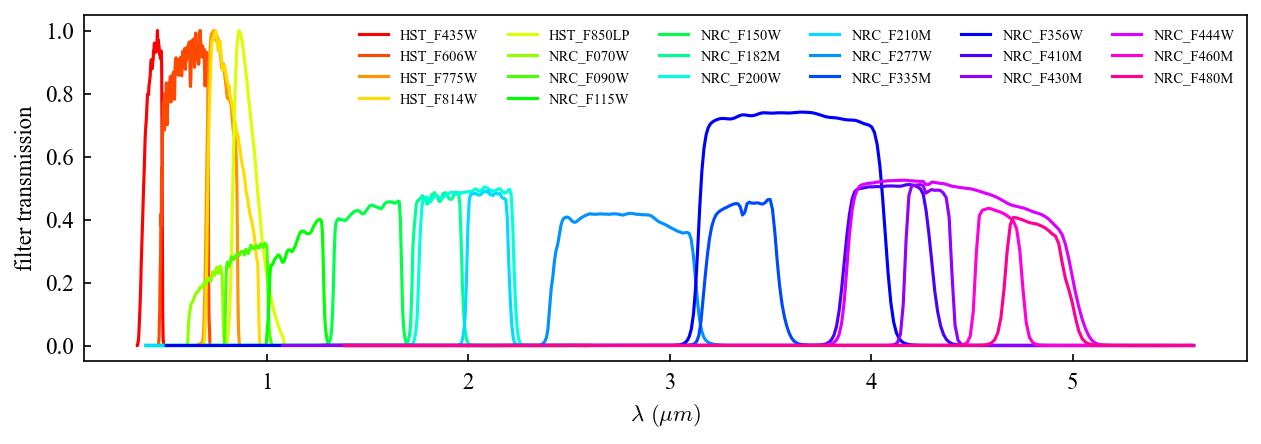

In [8]:
plt.figure(figsize=(10,3))
plt.xlabel('$\lambda\ (\mu m)$')
plt.ylabel('filter transmission')

# get distinct colors for different filters
colors = get_distinct_colors(len(filter_tr))

# plot filter transmissions
for f, c in zip(filter_tr, colors):
    lam = filter_tr[f]['lambda']
    ftspl = filter_tr[f]['ft_spl'](lam)
    ft = filter_tr[f]['filter_tr']
    plt.plot(lam, filter_tr[f]['ft_spl'](lam), color=c, label=f)

plt.legend(loc='best', frameon=False, ncol=6, fontsize=7)
plt.show()

The code below calls function `read_hainline_sample` that returns two nested dictionaries `seds` and `sed_templates`. 
The first dictionary `seds` contains a series of flux measurements for galaxies in different filters, their uncertainties, and the central wavelength of each filter. Measurements for each galaxy can be accessed as `seds[objid]['lambda']`, `seds[objid]['flux']` and `seds[objid]['flux_err']`, where `objid` is a string with JADES object ID and the first data is wavelength of the filter in microns ($1\,\mu =10^{-6}$ m) and the other two are the flux in a given filter in nano Janskys and its uncertainty.

16 model template spectra that can be used to fit the measured fluxes is in the dictionary `sed_templates`. Each template data can be accessed using integer key from `0` to `15`. For example, the wavelength (in micron) and flux (arbitrary normalization, the proper normalization will be determined in a fit to the data) of template 6 can be obtained by `sed_templates[5]['lambda']` and  `sed_templates[5]['flux']`. In addition, we can get `sed_templates[5]['fspl']` that can be used as a function `fspl(lam)` that returns flux of the template 6 for a given input wavelength in microns `lam`.

The code below shows how to read, access and plot galaxy data and spectral templates. 

In [9]:
seds, sed_templates = read_hainline_sample()

In [10]:
objids = []
# iterate over keys of dictionary seds 
# and add their names to the list objids
for obj in seds:
    objids.append(obj)
    
print(f'There are {len(objids):d} galaxies in the sample')

# print object IDs for galaxies 11 to 31
print(objids[10:30])

There are 211 galaxies in the sample
['JADES-GS-53.12721-27.79642', 'JADES-GS-53.12737-27.81805', 'JADES-GS-53.12919-27.80068', 'JADES-GS-53.1292-27.80825', 'JADES-GS-53.12949-27.81472', 'JADES-GS-53.13274-27.7967', 'JADES-GS-53.13368-27.80371', 'JADES-GS-53.13382-27.8167', 'JADES-GS-53.13506-27.79161', 'JADES-GS-53.13535-27.80596', 'JADES-GS-53.13549-27.76606', 'JADES-GS-53.13563-27.79185', 'JADES-GS-53.13593-27.78043', 'JADES-GS-53.13639-27.81306', 'JADES-GS-53.1387-27.79248', 'JADES-GS-53.13871-27.819', 'JADES-GS-53.13918-27.78273', 'JADES-GS-53.13969-27.76123', 'JADES-GS-53.14091-27.77279', 'JADES-GS-53.141-27.82825']


The code below illustrates how a given SED can be plotted for a putative redshift and a given `objid` along with a spectral template. 

In [11]:
def plot_sed_template(objid=None, seds=None, sed_templates=None, ftempl=None, 
                      ntempl=0, z=9.0, fnorm=0.2, figsize=(8, 3.5),
                      ylims=[0.001, 1000], xlims=[0., 6.]):
    """
    Plot measured SED for an object objid 
    
    Parameters:
        objid: str, JADES object ID
        seds: nested dictionary containing measured fluxes
        seds_templates: nested dictionary containing spectral template data
        ntempl: int, the number of template to use; must be in the range [0-15]
        z: float, redshift by which to redshift the template wavelengths
        fnorm: float, log10 of the normalization factor of the spectral template.
        figsize: tuple of 2 floats, figure size
        xlims, ylims: lists or tuples of size 2 with x and y axes ranges
        
    Returns:
        None
    """
    plt.figure(figsize=figsize)
    plt.title(objid)
    plt.yscale('log')
    plt.ylim(ylims)
    plt.xlim(xlims)
    plt.xlabel('wavelength (microns)')
    plt.ylabel('flux (nJy)')
    plt.errorbar(seds[objid]['lambda'], seds[objid]['flux'],yerr=seds[objid]['flux_err'], fmt='o')
    # extract wavelengths (in micron)
    lam = sed_templates[nt]['lambda']
    
    # compute model spectrum from the template
    fmodel = 10**fnorm * sed_templates[nt]['fspl'](lam) * lam**2

    # remove flux below Lyman alpha line to account for the IGM absorption
    isel = lam < 1215.67 / 1e4 
    fmodel[isel] = 0.

    # plot the redshifted template model SED
    plt.plot(lam*(1 + z), fmodel, label=f'$z = {z:.2f}$')

    if ftempl is not None: 
        plt.scatter(seds[objid]['lambda'], ftempl, marker='x', c='orangered', s=40., zorder=10)
    plt.legend(loc='lower right', frameon=False)
    plt.show()

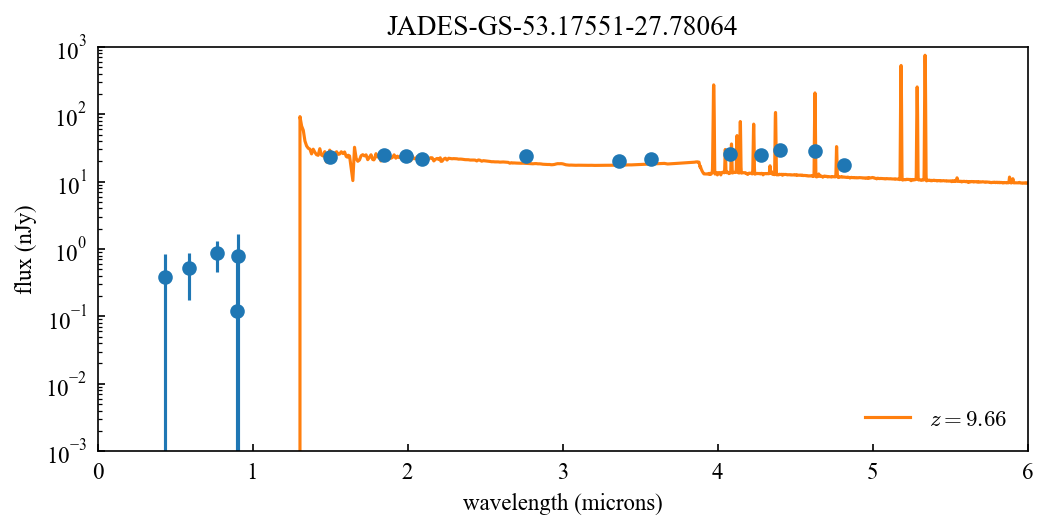

{'bands': array(['HST_F435W', 'HST_F606W', 'HST_F775W', 'HST_F850LP', 'NRC_F090W',
       'NRC_F150W', 'NRC_F182M', 'NRC_F200W', 'NRC_F210M', 'NRC_F277W',
       'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 'NRC_F430M', 'NRC_F444W',
       'NRC_F460M', 'NRC_F480M'], dtype='<U10'), 'lambda': array([0.43179, 0.5914 , 0.76933, 0.90364, 0.90229, 1.5007 , 1.8452 ,
       1.9886 , 2.0955 , 2.7623 , 3.3623 , 3.5682 , 4.0821 , 4.2813 ,
       4.4037 , 4.6302 , 4.8156 ]), 'flux': array([ 0.38176349,  0.53009206,  0.87766445,  0.7968002 ,  0.11866401,
       23.21260452, 24.44107056, 24.14258385, 21.41813087, 23.85208321,
       20.27568245, 21.52330971, 26.10057068, 24.98287582, 29.59967613,
       28.71239281, 17.51737022]), 'flux_err': array([0.45521978, 0.35615149, 0.42087543, 0.85090256, 0.74233729,
       1.16063023, 1.22205353, 1.20712919, 1.07090654, 1.19260416,
       1.01378412, 1.07616549, 1.30502853, 1.78569102, 1.47998381,
       2.2932291 , 1.77039552])}


In [12]:
objid = 'JADES-GS-53.17551-27.78064'

# choose the number of template, redshift, and log10 of template normalization
nt, z, fnorm = 12, 9.66, 0.9 

plot_sed_template(objid=objid, seds=seds, sed_templates=sed_templates, 
                  ntempl=nt, z=z, fnorm=fnorm)
print(seds[objid])


Finally, the code below shows how to compute model fluxes in a set of bands for this source using model template `nt=12` and redshift defined above. 

In [13]:
# list of filters, their wavelengths
# and measured fluxes and uncertainties for the source
# with object ID objid
bands = seds[objid]['bands']
lams = seds[objid]['lambda']
fluxes = seds[objid]['flux']
fluxes_err = seds[objid]['flux_err']

# initialize array for model fluxes
ftf = np.zeros_like(fluxes)

# iterate over bands
for i, b in enumerate(bands):
    # extract wavelengths and spline object 
    # approximating SED of template nt
    lamt = sed_templates[nt]['lambda']
    fspl = sed_templates[nt]['fspl']
    # construct a new spline approximation for
    # the redshifted SED template
    fspl = UnivariateSpline(lamt*(1+z), fspl(lamt), s=0.)

    # filter transmission curve for band b
    lamf = filter_tr[b]['lambda']
    # pivot wavelength for band b
    lam_pivot = filter_tr[b]['lambda_pivot']
    # spline object approximating transmission curve
    ft_spl = filter_tr[b]['ft_spl']
    # remove any flux at lambda < 1215 Angstroms
    # due to absorption by intergalactic hydrogen
    isel = lamf/(1+z) < (1215.67 / 1e4) 
    fmodel = fspl(lamf)
    fmodel[isel] = 0.

    # construct f(lambda) * T(\lambda) / int T(\lambda)d\lambda 
    ftfd = fmodel * ft_spl(lamf) / ft_spl.integral(lamf.min(), lamf.max())
    # approximate the flux converted to f_nu using spline
    ftf_spl = UnivariateSpline(lamf, ftfd*lam_pivot**2, s=0)
    # compute total flux f_nu in a band for comparison with observed one
    ftf[i] = ftf_spl.integral(lamf.min(), lamf.max())
    #print(b, lams[i], fluxes[i], fluxes_err[i], ftf[i])
    

In [14]:
# list of filters, their wavelengths
# and measured fluxes and uncertainties for the source
# with object ID objid
objid = 'JADES-GS-53.1106-27.81543'
nt = 7
z = 8.843
bands = seds[objid]['bands']
lams = seds[objid]['lambda']
fluxes = seds[objid]['flux']
fluxes_err = seds[objid]['flux_err']

# initialize array for model fluxes
ftf = np.zeros_like(fluxes)

# iterate over bands
for i, b in enumerate(bands):
    # extract wavelengths and spline object 
    # approximating SED of template nt
    lamt = sed_templates[nt]['lambda']
    fspl = sed_templates[nt]['fspl']
    # construct a new spline approximation for
    # the redshifted SED template
    fspl = UnivariateSpline(lamt*(1+z), fspl(lamt), s=0.)

    # filter transmission curve for band b
    lamf = filter_tr[b]['lambda']
    # pivot wavelength for band b
    lam_pivot = filter_tr[b]['lambda_pivot']
    # spline object approximating transmission curve
    ft_spl = filter_tr[b]['ft_spl']
    # remove any flux at lambda < 1215 Angstroms
    # due to absorption by intergalactic hydrogen
    isel = lamf/(1+z) < (1215.67 / 1e4) 
    fmodel = fspl(lamf)
    fmodel[isel] = 0.

    # construct f(lambda) * T(\lambda) / int T(\lambda)d\lambda 
    ftfd = fmodel * ft_spl(lamf) / ft_spl.integral(lamf.min(), lamf.max())
    # approximate the flux converted to f_nu using spline
    ftf_spl = UnivariateSpline(lamf, ftfd*lam_pivot**2, s=0)
    # compute total flux f_nu in a band for comparison with observed one
    ftf[i] = ftf_spl.integral(lamf.min(), lamf.max())
    #print(b, lams[i], fluxes[i], fluxes_err[i], ftf[i])
    

The fluxes for this object computed using the above code are shown as red crosses in the plot below and can be compared to the blue circles showing measured fluxes. 

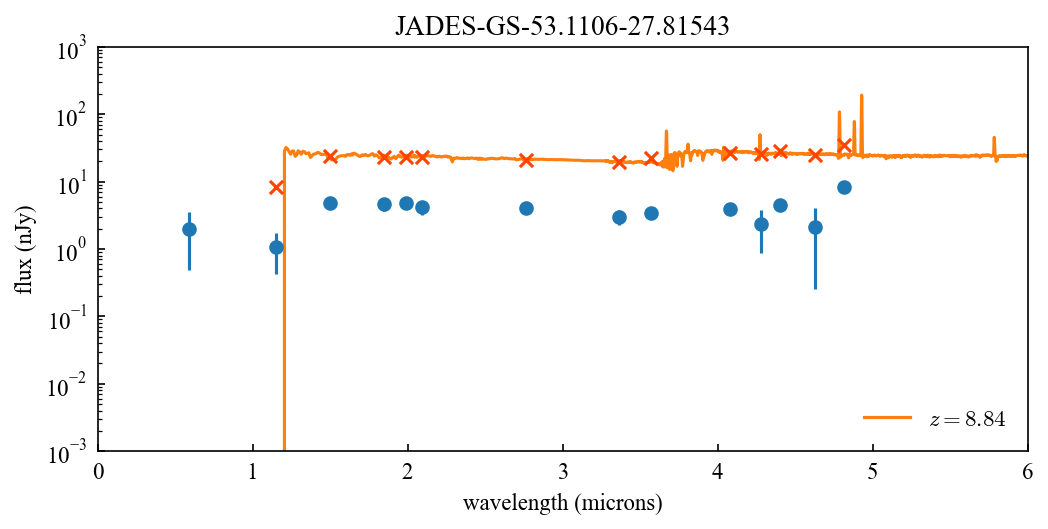

In [15]:
# arbitray normalization
ftf = 0.08 * ftf

plot_sed_template(objid=objid, seds=seds, sed_templates=sed_templates, 
                  ntempl=nt, z=z, fnorm=fnorm, ftempl=ftf)

In [16]:
## Part 1 
seds, sed_templates = read_hainline_sample()
filter_tr = read_filters()
def compute_flux(nt, z, band):
    nt = math.floor(nt)
    lamt = sed_templates[nt]['lambda']
    fspl = sed_templates[nt]['fspl']
    # Compute redshifted wavelength values
    lamt_redshifted = lamt * (1 + z)
    # Sort the redshifted wavelength values
    sorted_indices = np.argsort(lamt_redshifted)
    lamt_redshifted_sorted = lamt_redshifted[sorted_indices]
    fspl_sorted = fspl(lamt[sorted_indices])
    fspl_spline = UnivariateSpline(lamt_redshifted_sorted, fspl_sorted, s=0.)
    lamf = filter_tr[band]['lambda']
    lam_pivot = filter_tr[band]['lambda_pivot']
    ft_spl = filter_tr[band]['ft_spl']
    isel = lamf / (1 + z) < 1215.67 / 1e4
    fmodel = fspl_spline(lamf)
    fmodel[isel] = 0.
    # construct f(lambda) * T(\lambda) / int T(\lambda)d\lambda
    ftfd = fmodel * ft_spl(lamf) / ft_spl.integral(lamf.min(), lamf.max())
    # approximate the flux converted to f_nu using spline
    ftf_spline = UnivariateSpline(lamf, ftfd * lam_pivot**2, s=0)
    # compute total flux f_nu in a band for comparison with observed one
    ftf = ftf_spline.integral(lamf.min(), lamf.max())
    return ftf
def likel(params, *args):
    if len(params) == 3:
        nt,nf,z = params
    else:
        nt = args[3]
        nf,z = params
    objid = args[0][0]
    bounds = args[0][1]
    nfmin, nfmax = bounds[1]
    zmin, zmax = bounds[2]
    if (z < zmin) or (z > zmax) or (nf < nfmin) or (nf > nfmax):
        prior =  -1000.
    else:
        prior =  0
    bands = seds[objid]['bands']
    lams = seds[objid]['lambda']
    fluxes = seds[objid]['flux']
    fluxes_err = seds[objid]['flux_err']
    ftf = np.zeros_like(fluxes)
    # initialize array for model fluxes
    fb = np.zeros_like(fluxes)
    tfb = np.zeros_like(fluxes)
    # iterate over bands
    summ = []
    for i, b in enumerate(bands):
        lam_pivot = filter_tr[b]['lambda_pivot']
        fb[i]  = compute_flux(nt, z, b)
        tfb[i] = (10**nf)*fb[i]
        summ.append((fluxes[i] - tfb[i])**2 / (fluxes_err[i]**2))
    ll = -0.5*np.sum((fluxes - tfb)**2 / (fluxes_err**2))
    return ll + prior
def minus_ln_pdf(params, *args):
    return -likel(params,*args)     
def chisq(params,*args):
    objid = args[0]
    return -2* likel(params,*args)/ (len (seds[objid]['bands']) - 3)

In [17]:
params = np.array([7,-1.86,8.843])
param_bounds = [(0, 15),(-10, 10),(0, 20)]
objid = 'JADES-GS-53.1106-27.81543'
args = [objid,param_bounds]
print(minus_ln_pdf(params,args))

6.8185891087800865


In [18]:
params = np.array([7,-1.73,9.006])
args = [objids[3],param_bounds]
print(likel(params,args))
min_chi = (-2* likel(params,args))/ (len(seds[objids[3]]['bands']) - 3)
print(min_chi)

-5.171227257041898
1.1491616126759774


In [19]:
params = np.array([14,-1.12946443, 12.13663582])
args = [objids[3],param_bounds]
print(likel(params,args))
min_chi = (-2* likel(params,args))/ (len(seds[objids[3]]['bands']) - 3)
print(min_chi)

-5.153300488912089
1.1451778864249087


In [20]:
def minimize_de(func, x0, *args, atol = 1e-8, s = 0.1, bounds = None):
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    for dim in range(ndim):
        xmin = bounds[dim][0]
        xmax = bounds[dim][1]
        for i in range(npop):
            x0[i,dim] = xmin + (xmax-xmin) * np.random.uniform(0,1)
    if bounds is not None:
        for x in x0:
            x[0] = np.clip(x[0], bounds[0][0], bounds[0][1])
            x[0] = math.floor(x[0])
            x[1] = np.clip(x[2], bounds[1][0], bounds[1][1])
            x[2] = np.clip(x[2], bounds[2][0], bounds[2][1])
    xnow = np.copy(x0)
    print('DE ARGS',args)
    fnow = np.array([func(x, *args) for x in x0])
    xnext = np.zeros_like(x0)
    while True:
        for i in range(npop):
            inds = np.arange(0,npop)
            inds = np.delete(inds,i)
            np.random.shuffle(inds)
            ir1, ir2, ir3 = inds[:3]     
            scale_factor = np.random.uniform(s, 1)
            xtry = xnow[ir3] + scale_factor * (xnow[ir1] - xnow[ir2])
            xtry[0] = np.clip(xtry[0], bounds[0][0], bounds[0][1])
            xtry[0] = math.floor(xtry[0])
            xtry[1] = np.clip(xtry[1], bounds[1][0], bounds[1][1])
            xtry[2] = np.clip(xtry[2], bounds[2][0], bounds[2][1])
            ftry = func(xtry, *args)
            if ftry <= fnow[i]:
                xnext[i] = xtry
                fnow[i] = ftry
            else:
                xnext[i] = xnow[i]
        if np.max(np.abs(xnext - xnow)) < atol and np.max(np.abs(xnext - xnow)) > 0:
            break
        xnow = np.copy(xnext) 
    min_index = np.argmin(fnow)
    return xnow[min_index],fnow[min_index]
def likel(params, *args):
    if len(params) == 3:
        nt,nf,z = params
    else:
        nt = args[3]
        nf,z = params
    objid = args[0]
    nfmin, nfmax = args[1][1]
    zmin, zmax = args[1][2]
    if (z < zmin) or (z > zmax) or (nf < nfmin) or (nf > nfmax):
        prior =  -1000.
    else:
        prior =  0
    bands = seds[objid]['bands']
    lams = seds[objid]['lambda']
    fluxes = seds[objid]['flux']
    fluxes_err = seds[objid]['flux_err']
    ftf = np.zeros_like(fluxes)
    # initialize array for model fluxes
    fb = np.zeros_like(fluxes)
    tfb = np.zeros_like(fluxes)
    # iterate over bands
    summ = []
    for i, b in enumerate(bands):
        lam_pivot = filter_tr[b]['lambda_pivot']
        fb[i]  = compute_flux(nt, z, b)
        tfb[i] = (10**nf)*fb[i]
        summ.append((fluxes[i] - tfb[i])**2 / (fluxes_err[i]**2))
    ll = -0.5*np.sum((fluxes - tfb)**2 / (fluxes_err**2))
    return ll + prior

In [21]:
def minimize_de(func, x0, *args, atol=1e-8, s=0.1, cr=0.7, crossover=True, bounds=None):
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    for dim in range(ndim):
        xmin = bounds[dim][0]
        xmax = bounds[dim][1]
        for i in range(npop):
            x0[i, dim] = xmin + (xmax - xmin) * np.random.uniform(0, 1)
    if bounds is not None:
        for x in x0:
            x[0] = np.clip(x[0], bounds[0][0], bounds[0][1])
            x[0] = math.floor(x[0])
            x[1] = np.clip(x[2], bounds[1][0], bounds[1][1])
            x[2] = np.clip(x[2], bounds[2][0], bounds[2][1])
    xnow = np.copy(x0)
    fnow = np.array([func(x, *args) for x in x0])
    xnext = np.zeros_like(x0)
    while True:
        for i in range(npop):
            inds = np.arange(0, npop)
            inds = np.delete(inds, i)
            np.random.shuffle(inds)
            ir1, ir2, ir3 = inds[:3]
            scale_factor = np.random.uniform(s, 1)
            xmut = xnow[ir3] + scale_factor * (xnow[ir1] - xnow[ir2])
            xmut[0] = np.clip(xmut[0], bounds[0][0], bounds[0][1])
            xmut[0] = math.floor(xmut[0])
            xmut[1] = np.clip(xmut[1], bounds[1][0], bounds[1][1])
            xmut[2] = np.clip(xmut[2], bounds[2][0], bounds[2][1])
            xtry= np.zeros_like(xmut)
            if crossover:
                for i2 in range(len(xnow[i])):
                    if np.random.uniform(0, 1) <= cr:
                        xtry[i2] = xmut[i2]
                    else:
                        xtry[i2] = xnow[i][i2]
            else:
                xtry = xmut
            ftry = func(xtry, *args)
            xtry[0] = np.clip(xtry[0], bounds[0][0], bounds[0][1])
            xtry[0] = math.floor(xtry[0])
            xtry[1] = np.clip(xtry[1], bounds[1][0], bounds[1][1])
            xtry[2] = np.clip(xtry[2], bounds[2][0], bounds[2][1])
            if ftry <= fnow[i]:
                xnext[i] = xtry
                fnow[i] = ftry
            else:
                xnext[i] = xnow[i]
        if np.max(np.abs(xnext - xnow)) < atol and np.max(np.abs(xnext - xnow)) > 0:
            break
        xnow = np.copy(xnext)
    best_index = np.argmin(fnow)
    return xnow[best_index], fnow[best_index]

In [290]:
import random 
npop = 60
x0 = np.array([ [ np.random.randint(0, 15), np.random.uniform(-10, 10),np.random.uniform(0, 20)]  for _ in range(npop)])
# Bounds for parameters
param_bounds = [(0, 15),(-10, 10),(0, 20)]
bf_params = []
chi_lst = []
args = [objids[3], param_bounds]
# Minimization using minimize_de
result = minimize_de(minus_ln_pdf, x0, *args, s = 0.1, bounds = param_bounds)
# Best-fit parameters and minimum chi-square
bf_params.append(result[0].tolist()) 
print('OBJID',objids[3])
print('OWN best fit params',result[0])
print('min Like',result[1])
min_chi = (2* result[1])/ (len(seds[objids[3]]['bands']) - 3)
chi_lst.append(min_chi)
print('reduced chi-square',min_chi)

OBJID JADES-GS-53.11685-27.80056
OWN best fit params [ 1.         -0.67115046  9.16512844]
min Like 8.255887921632246
reduced chi-square 1.8346417603627212


[0.00000000e+00 1.31326040e-02 8.53874010e+01 3.15736832e+02
 3.00872013e+02 3.02103392e+02 3.00590282e+02 2.76078440e+02
 2.53042750e+02 2.83361662e+02 3.46548559e+02 3.62782676e+02]
1.333569437624527


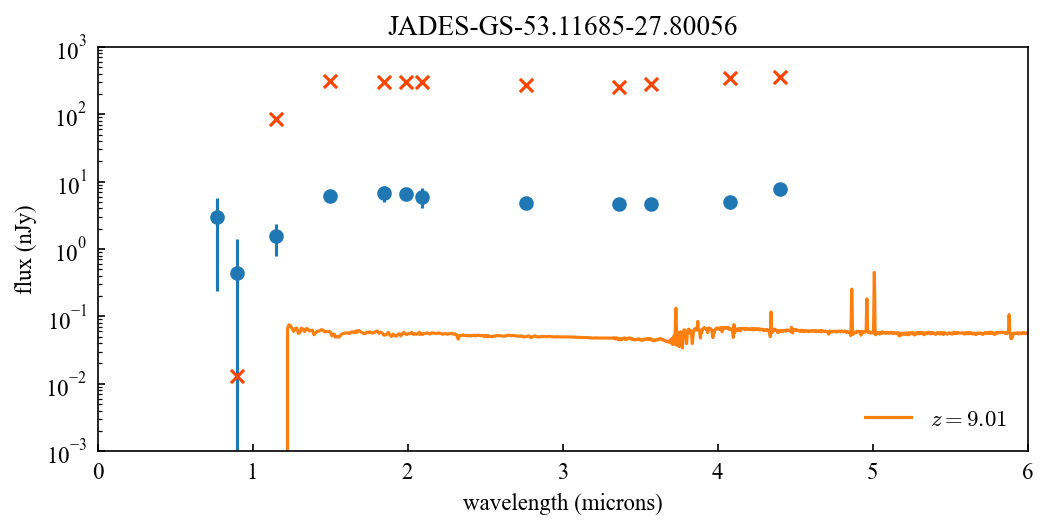

In [294]:
bands = seds[objids[3]]['bands']
lams = seds[objids[3]]['lambda']
fluxes = seds[objids[3]]['flux']
fluxes_err = seds[objids[3]]['flux_err']
# initialize array for model fluxes
ftf = np.zeros_like(fluxes)
nt,fnorm,z = bf_params[0]
# iterate over bands
for i, b in enumerate(bands):
    ftf[i] = compute_flux(nt,z,b)
flux = seds[objid]['flux']
fmod_spl = sed_templates[nt]['fspl']
# rough normalization of the template for comparison
lamz = lam / (1+z)
fmod_norm = np.median(flux) / np.median(fmod_spl(lamz) * lamz**2)
print(ftf)
print(fmod_norm)
plot_sed_template(objid=objids[3], seds=seds, sed_templates=sed_templates, ntempl=nt, z=z, fnorm=fnorm, ftempl= ftf)

In [292]:
import random 
npop = 60
x0 = np.array([ [ np.random.randint(0, 15), np.random.uniform(-10, 10),np.random.uniform(0, 20)]  for _ in range(npop)])
# Bounds for parameters
param_bounds = [(0, 15),(-10, 10),(0, 20)]
bf_params = []
chi_lst = []
args = [objids[3], param_bounds]
# Minimization using minimize_de
result = minimize_de(chisq, x0, *args, s = 0.1, bounds = param_bounds)
# Best-fit parameters and minimum chi-square
bf_params.append(result[0].tolist()) 
print('OBJID',objids[3])
print('OWN best fit params',result[0])
print('min Like',result[1])
min_chi = (2* result[1])/ (len(seds[objids[3]]['bands']) - 3)
chi_lst.append(min_chi)
print('reduced chi-square',min_chi)

OBJID JADES-GS-53.11685-27.80056
OWN best fit params [ 7.         -1.73093099  9.00589685]
min Like 1.148872120079424
reduced chi-square 0.25530491557320534


[0.00000000e+00 1.31326040e-02 8.53874010e+01 3.15736832e+02
 3.00872013e+02 3.02103392e+02 3.00590282e+02 2.76078440e+02
 2.53042750e+02 2.83361662e+02 3.46548559e+02 3.62782676e+02]
1.333569437624527


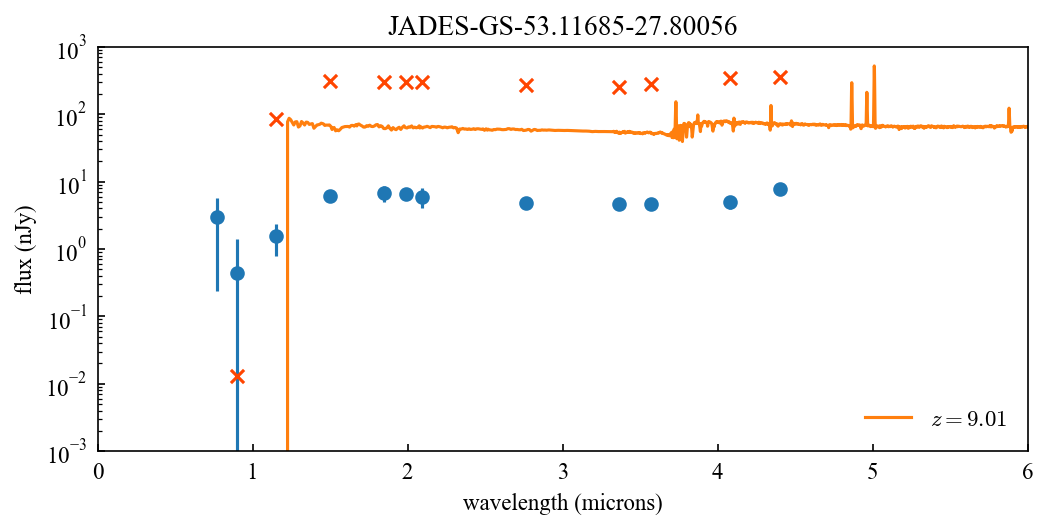

In [318]:
bands = seds[objids[3]]['bands']
lams = seds[objids[3]]['lambda']
fluxes = seds[objids[3]]['flux']
fluxes_err = seds[objids[3]]['flux_err']
# initialize array for model fluxes
ftf = np.zeros_like(fluxes)
nt,fnorm,z = bf_params[0]
# iterate over bands
for i, b in enumerate(bands):
    ftf[i] = compute_flux(nt,z,b)
flux = seds[objid]['flux']
fmod_spl = sed_templates[nt]['fspl']
# rough normalization of the template for comparison
lamz = lam / (1+z)
fmod_norm = np.median(flux) / np.median(fmod_spl(lamz) * lamz**2)
print(ftf)
print(fmod_norm)
plot_sed_template(objid=objids[3], seds=seds, sed_templates=sed_templates, ntempl=nt, z=z, fnorm=fmod_norm, ftempl= ftf)

In [ ]:
npop = 60
x0 = np.array([ [ np.random.randint(0, 15), np.random.uniform(-10, 10),np.random.uniform(0, 20)]  for _ in range(npop)])
param_bounds = [(0, 15),(-10, 10),(0, 20)]
bf_params = []
chi_lst = []
for i,x in enumerate(objids[:10]):
    print(i)
    args = [x, param_bounds]
    # Minimization using minimize_de
    result = minimize_de(minus_ln_pdf, x0, *args, s = 0.1, bounds = param_bounds)
    # Best-fit parameters and minimum chi-square
    bf_params.append(result[0].tolist()) 
    print('OBJID',x)
    print('OWN best fit params',result[0])
    print('min LLike',result[1])
    min_chi = (2* result[1])/ (len(seds[x]['bands']) - 3)
    chi_lst.append(min_chi)
    print('reduced chi-square',min_chi)


0
OBJID JADES-GS-53.10776-27.81294
OWN best ift params [14.          0.23315861  2.10658762]
min LLike 18.659269396758784
reduced chi-square 3.3925944357743245
1
OBJID JADES-GS-53.1106-27.81543
OWN best ift params [ 7.         -1.85680119  8.81027563]
min LLike 6.813107195717272
reduced chi-square 1.2387467628576858
2
OBJID JADES-GS-53.11392-27.79584
OWN best ift params [10.          0.07659662  2.44509234]
min LLike 45.2840294200694
reduced chi-square 8.233459894558074
3
OBJID JADES-GS-53.11685-27.80056
OWN best ift params [ 7.         -1.73093099  9.00589685]
min LLike 5.1699245403574325
reduced chi-square 1.1488721200794294
4
OBJID JADES-GS-53.11711-27.80797
OWN best ift params [ 9.         -0.42333208  2.75482536]
min LLike 7.732586917081174
reduced chi-square 1.4059248940147588
5


In [ ]:
print(bf_params)

In [32]:
def mcmc_de(x0,*args, b, d, logpdf = None, nsteps = 10000, bounds = None):
    print('MCMC',args)
    gamma = 2.38 / np.sqrt(d)
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    xnow = np.copy(x0)
    fnow = np.array([logpdf(x, *args) for x in x0])
    xchain = np.zeros((nsteps, npop, ndim))  # Store all parameter samples
    fchain = np.zeros((nsteps, npop))
    for ii in range(nsteps):
        for i in range(npop):
            inds = np.arange(0, npop)
            inds = np.delete(inds, i)
            np.random.shuffle(inds)
            ir1, ir2 = inds[:2]
            ee = np.random.uniform(-b, b)
            xtry = xnow[i] + gamma * (xnow[ir1] - xnow[ir2]) + ee
            xtry[0] = np.clip(xtry[0], bounds[1][0], bounds[1][1])
            xtry[1] = np.clip(xtry[1], bounds[2][0], bounds[2][1])
            ftry = logpdf(xtry, *args)
            f1 = logpdf(xnow[i], *args)
            u = np.log(np.random.uniform(0, 1))
            if u <= ftry - f1:
                xnow[i] = xtry
                fnow[i] = ftry
        # Store the samples at each step
        xchain[ii] = xnow
        fchain[ii] = fnow

    # Return the last sample as the best-fit parameters
    best_index = np.argmax(fnow)
    return xnow[best_index], fnow[best_index], xchain, fchain

In [35]:
def likel(params, *args):
    if len(params) == 3:
        nt,nf,z = params
    else:
        nt = args[2]
        nf,z = params
    objid = args[0]
    bounds = args[1]
    nfmin, nfmax = bounds[1]
    zmin, zmax = bounds[2]
    if (z < zmin) or (z > zmax) or (nf < nfmin) or (nf > nfmax):
        prior =  -1000.
    else:
        prior =  0
    bands = seds[objid]['bands']
    lams = seds[objid]['lambda']
    fluxes = seds[objid]['flux']
    fluxes_err = seds[objid]['flux_err']
    ftf = np.zeros_like(fluxes)
    # initialize array for model fluxes
    fb = np.zeros_like(fluxes)
    tfb = np.zeros_like(fluxes)
    # iterate over bands
    summ = []
    for i, b in enumerate(bands):
        lam_pivot = filter_tr[b]['lambda_pivot']
        fb[i]  = compute_flux(nt, z, b)
        tfb[i] = (10**nf)*fb[i]
        summ.append((fluxes[i] - tfb[i])**2 / (fluxes_err[i]**2))
    ll = -0.5*np.sum((fluxes - tfb)**2 / (fluxes_err**2))
    return ll + prior
def minus_ln_pdf(params, *args):
    return -likel(params,*args) 
ndim, nwalkers, nsteps = 2, 30, 1000
pchain = []
unc1  = np.zeros( (ndim,len(objids)) )
unc2  = np.zeros( (ndim,len(objids)) )
bf_params = np.array([ 7,-1.73093099,9.00589685])
objids[3]
arg = [objids[3], param_bounds, bf_params[0]]
initial_positions = np.array([ [bf_params[1]* np.random.uniform(0.95, 0.99), bf_params[2] * np.random.uniform(0.95, 0.99)]  for _ in range(nwalkers)])
result_mcmc = mcmc_de(initial_positions, *args,b = 0.1, d = 5, logpdf = minus_ln_pdf, nsteps = nsteps, bounds = param_bounds)
pchain.append(result_mcmc[2])
z_chain = pchain[i][:, :, 1].flatten()
z15 = np.percentile( z_chain,15.865)
z84 = np.percentile( z_chain,84.135)
unc1[0][i] = bf_params[i][2] - z15
unc1[1][i] = z84 - bf_params[i][2]
z2  = np.percentile( z_chain,2.28)
z98 = np.percentile( z_chain,97.73)
unc2[0][i] = bf_params[i][2] - z2
unc2[1][i] = z98 - bf_params[i][2]    
unc2 = np.abs(np.array(unc2))
unc1 = np.abs(np.array(unc1))

# Plotting measured redshifts with error bars
plt.figure(figsize=(10, 6))
for i, objid in enumerate(objids[:10]):
    
    plt.errorbar(i, bf_params[i][2], yerr=[[unc1[0][i]], [unc1[1][i]]], fmt='o', color='blue', label=f'{objid} (MCMC 1$\sigma$)')
    plt.errorbar(i, bf_params[i][2], yerr=[[unc2[0][i]], [unc2[1][i]]], fmt='x', color='red', label=f'{objid} (MCMC 2$\sigma$)')

plt.xticks(range(len(objids)), objids, rotation=45, ha='right')
plt.xlabel('Object ID')
plt.ylabel('Redshift')
plt.title('Measured Redshifts with Error Bars')
plt.legend()
plt.tight_layout()
plt.show()


MCMC ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10)

LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53

LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53

LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53

LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53.11685-27.80056', [(0, 15), (-10, 10), (0, 20)], 7.0)
LIKEL [(0, 15), (-10, 10), (0, 20)]
LIKEL ('JADES-GS-53

KeyboardInterrupt: 

In [ ]:
ndim, nwalkers, nsteps = 2, 30, 1000
pchain = []
unc1  = np.zeros( (ndim,len(objids)) )
unc2  = np.zeros( (ndim,len(objids)) )
bf_params = np.array(bf_params)
for i,x in enumerate(objids[:10]):
    print(i)
    args = [x, param_bounds, bf_params[i][0]]
    initial_positions = np.array([ [bf_params[i][1]* np.random.uniform(0.95, 0.99), bf_params[i][2] * np.random.uniform(0.95, 0.99)]  for _ in range(nwalkers)])
    result_mcmc = mcmc_de(initial_positions, b = 0.1, d = 5, logpdf = likel, args = *args, nsteps = nsteps, bounds = param_bounds)
    pchain.append(result_mcmc[2])
    z_chain = pchain[i][:, :, 1].flatten()
    z15 = np.percentile( z_chain,15.865)
    z84 = np.percentile( z_chain,84.135)
    unc1[0][i] = bf_params[i][2] - z15
    unc1[1][i] = z84 - bf_params[i][2]
    z2  = np.percentile( z_chain,2.28)
    z98 = np.percentile( z_chain,97.73)
    unc2[0][i] = bf_params[i][2] - z2
    unc2[1][i] = z98 - bf_params[i][2]    
unc2 = np.abs(np.array(unc2))
unc1 = np.abs(np.array(unc1))

# Plotting measured redshifts with error bars
plt.figure(figsize=(10, 6))
for i, objid in enumerate(objids[:10]):
    
    plt.errorbar(i, bf_params[i][2], yerr=[[unc1[0][i]], [unc1[1][i]]], fmt='o', color='blue', label=f'{objid} (MCMC 1$\sigma$)')
    plt.errorbar(i, bf_params[i][2], yerr=[[unc2[0][i]], [unc2[1][i]]], fmt='x', color='red', label=f'{objid} (MCMC 2$\sigma$)')

plt.xticks(range(len(objids)), objids, rotation=45, ha='right')
plt.xlabel('Object ID')
plt.ylabel('Redshift')
plt.title('Measured Redshifts with Error Bars')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from astropy.cosmology import LambdaCDM
import astropy.units as u
def d_l_astropy(z,H0, om0, oml):
    cosmo = LambdaCDM(H0=H0, Om0=om0, Ode0=oml)
    return cosmo.luminosity_distance(z=z) / u.Mpc
# Assuming bf_params is a numpy array
bf_params = np.array(bf_params)

# Get the indices that would sort bf_params based on redshifts (assuming redshift is at index 2)
sorted_indices = np.argsort(bf_params[:, 2])

# Plotting measured redshifts with error bars
plt.figure(figsize=(10, 6))
for i, objid in enumerate(objids[:10]):
    sorted_i = sorted_indices[i]
    plt.errorbar(i, bf_params[sorted_i][2], yerr=[[unc2[0][sorted_i]], [unc2[1][sorted_i]]], fmt='x', color='red')
    plt.errorbar(i, bf_params[sorted_i][2], yerr=[[unc1[0][sorted_i]], [unc1[1][sorted_i]]], fmt='o', color='blue')

plt.xlabel('Object ID')
plt.ylabel('Redshift')
plt.title('Measured Redshifts with Error Bars, Blue = +_ sigma, Red +_ 2 sigma')
plt.legend()
plt.tight_layout()
plt.show()
print('Distiance of Highest Redshift Source',d_l_astropy(bf_params[sorted_indices[9]][2],70,0.26,0.74))
